### Import modules

In [16]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import scipy.stats as stats
import numpy as np
from importlib import reload
plt=reload(plt)
from scipy.stats import pearsonr
import sklearn
from sklearn.metrics import r2_score

### Read in the profile files

In [2]:
bnDist=pd.read_csv("/scicomp/home-pure/uge1/MLST/bionumerics_data/stecDist_BN.txt",sep="\t")
bnDist.rename({'sample1':'BN_sample1','sample2':'BN_sample2','identity':'BN_identity','numSame':'BN_numAllelesSame','numCompared':'BN_numLociCompared'}, axis=1,inplace=True)

hashDist = pd.read_csv("/scicomp/home-pure/uge1/MLST/hash-cgmlst/stecResults_01_14_25/stec.distances.tsv",sep="\t",skipinitialspace=True)
hashDist.rename({'hash_num_alleles_same':'hash_numAllelesSame','hash_num_loci_compared':'hash_numLociCompared','total_loci':'hash_totalLoci'}, axis=1,inplace=True)

kmaDist = pd.read_csv("/scicomp/home-pure/uge1/MLST/kma-cgmlst/stecResults_01_14_25/stec.dist.tsv",sep="\t")
kmaDist.rename({'kma_num_alleles_same':'kma_numAllelesSame','kma_num_loci_compared':'kma_numLociCompared'},axis=1,inplace=True)

etokiDist = pd.read_csv("/scicomp/home-pure/uge1/MLST/etoki/stec/stecResults_01_15_24/stec.dist.tsv",sep="\t")
etokiDist.rename({'fasta1':'etoki_sample1','fasta2':'etoki_sample2','dist':'etoki_identity','numAllelesSame':'etoki_numAllelesSame','numLociSame':'etoki_numLociCompared'}, axis=1,inplace=True)

chewieDist = pd.read_csv("/scicomp/home-pure/uge1/MLST/chewie/stecResults_01_24_25/stec.dist.tsv",sep="\t")
chewieDist.rename({'sample1':'chewie_sample1','sample2':'chewie_sample2','identity':'chewie_identity','numSame':'chewie_numLociSame','numCompared':'chewie_numLociCompared'
                   ,'sample1loci':'chewie_sample1loci','sample2loci':'chewie_sample1loci'}, axis=1,inplace=True)

colorDist = pd.read_csv("/scicomp/home-pure/uge1/MLST/colorid/stecResults_01_31_25/stec.colorid.dist.tsv",sep=",")
colorDist.rename({'colorid_num_alleles_same':'colorid_numAllelesSame','colorid_num_loci_compared':'colorid_numLociCompared','colorid_total_loci':'colorid_totalLoci'}, axis=1, inplace=True)

pnDist = pd.read_csv("/scicomp/home-pure/uge1/MLST/pn2.0/stec/stec.dist.tsv",sep="\t")
pnDist.rename({'sample1':'PN_sample1','sample2':'PN_sample2','identity':'PN_identity','numSame':'PN_numAllelesSame','numCompared':'PN_numLociCompared'}, axis=1,inplace=True)

### Create a key column for comparison

In [3]:
bnDist['key'] = bnDist[['BN_sample1','BN_sample2']].apply('-'.join,axis=1)

hashDist['key'] = hashDist[['hash_sample1','hash_sample2']].apply('-'.join,axis=1)

kmaDist['key'] = kmaDist[['kma_sample1','kma_sample2']].apply('-'.join,axis=1)

etokiDist['key'] = etokiDist[['etoki_sample1','etoki_sample2']].apply('-'.join,axis=1)

chewieDist['key'] = chewieDist[['chewie_sample1','chewie_sample2']].apply('-'.join,axis=1)

colorDist['key'] = colorDist[['colorid_sample1','colorid_sample2']].apply('-'.join,axis=1)

pnDist['key'] = pnDist[['PN_sample1','PN_sample2']].apply('-'.join,axis=1)

In [4]:
dfmerged = pd.merge(pd.merge(pd.merge(pd.merge(pd.merge(pd.merge(bnDist,etokiDist,on='key'),hashDist,on='key'),kmaDist,on="key"),chewieDist,on='key'),colorDist,on='key'),pnDist,on='key')

In [5]:
#Loci in the schema for stec is 2514
minLoci = 0.85*2514

In [6]:
dfFiltered = dfmerged[(dfmerged['BN_numLociCompared'] > minLoci) & (dfmerged['hash_numLociCompared'] >  minLoci) 
                      & (dfmerged['etoki_numLociCompared'] > minLoci) & (dfmerged['kma_numLociCompared'] > minLoci) 
                      & (dfmerged['chewie_numLociCompared'] > minLoci) & (dfmerged['colorid_numLociCompared'] > minLoci)
                     & (dfmerged['PN_numLociCompared'] > minLoci)]

In [7]:
len(dfmerged)

40368

### Create distance plots

In [8]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
x1 = dfFiltered.BN_identity.values.reshape(-1,1)
y1 = dfFiltered.hash_identity.values.reshape(-1,1) /100
model.fit(x1,y1)
yPred=model.predict(x1)

#Calculating the slope
slope = model.coef_[0][0]
intercept = model.intercept_[0]

# Calculate Pearson correlation coefficient
corr_coefficient, _ = stats.pearsonr(x1[:,0].flatten(), y1[:,0])

#Calculating the CI of r2 95%
z = np.arctanh(corr_coefficient)
se = 1/np.sqrt(len(x1)-3)
z_critical = stats.norm.ppf(0.975)
z_lower = z - z_critical * se
z_upper = z + z_critical * se
r_lower = np.tanh(z_lower)
r_upper = np.tanh(z_upper)

print(f'r^2 is {corr_coefficient}:[{r_lower},{r_upper}]')

residuals = y1 - yPred
n = len(y1)
p = 1 #no. of predictors
df = n - p - 1
#slope std err
s_xx = np.sum((x1 - np.mean(x1))**2)
residual_stderr = np.sqrt(np.sum(residuals**2)/df)
slope_se = residual_stderr/np.sqrt(s_xx)
#CI for slope
t_critical = stats.t.ppf(1 - 0.05 / 2, df) #alpha is 0.05 for 95% CI
margin_of_error = t_critical * slope_se
lower_bound = slope - margin_of_error
upper_bound = slope + margin_of_error

print(f'slope 95% CI:({lower_bound},{upper_bound})')

#Creating the regression equation
regEq = f'y = {slope:.2f}x + {intercept: .2f}'

# fig = plt.figure()
# #plt.scatter(dfFiltered.BN_identity,dfFiltered.hash_identity)
# plt.scatter(x1,y1)
# #plt.ylim(0,1)
# plt.plot(x1,yPred,color="red")
# plt.title("hash-cgMLST versus BioNumerics identities for STEC")
# plt.xlabel('BioNumerics identity')
# plt.ylabel('hash-cgMLST identity')

# plt.text(0.1, 0.9, regEq, transform=plt.gca().transAxes, fontsize=12)

# plt.annotate("r-squared = {:.3f}".format(r2_score(y1, yPred)), (0.17, 0.5),fontsize=9)
# # plt.savefig("/scicomp/home-pure/uge1/MLST/hash-cgmlst/stecResults_01_14_25/stecHashVsBN.png")
# plt.show()

r^2 is 0.9999723520455032:[0.9999718073220148,0.9999728862442852]
slope 95% CI:(0.9973738544772215,0.997518574373992)


In [9]:
#kma-cgmlst vs BioNumerics

model2 = LinearRegression()
x2 = dfFiltered.BN_identity.values.reshape(-1,1)
y2 = dfFiltered.kma_identity.values.reshape(-1,1) /100
model2.fit(x2,y2)
y2Pred=model2.predict(x2)

#Calculating the slope
slope2 = model2.coef_[0][0]
intercept2 = model2.intercept_[0]

#Creating the regression equation
regEq2 = f'y = {slope2:.2f}x + {intercept2: .2f}'
corr_coefficient2, p_value2 = stats.pearsonr(x2[:,0].flatten(), y2[:,0])

#Calculating the CI of r2 95%
z2 = np.arctanh(corr_coefficient2)
se2 = 1/np.sqrt(len(x2)-3)
z2_critical = stats.norm.ppf(0.975)
z2_lower = z2 - z2_critical * se2
z2_upper = z2 + z2_critical * se2
r2_lower = np.tanh(z2_lower)
r2_upper = np.tanh(z2_upper)

print(f'r^2 is {corr_coefficient2}:[{r2_lower},{r2_upper}]')

residuals2 = y2 - y2Pred
n2 = len(y2)
p = 1 #no. of predictors
df = n - p - 1
#slope std err
s2_xx = np.sum((x2 - np.mean(x2))**2)
residual2_stderr = np.sqrt(np.sum(residuals2**2)/df)
slope2_se = residual2_stderr/np.sqrt(s2_xx)
#CI for slope
t_critical = stats.t.ppf(1 - 0.05 / 2, df) #alpha is 0.05 for 95% CI
margin_of_error = t_critical * slope2_se
lower2_bound = slope2 - margin_of_error
upper2_bound = slope2 + margin_of_error

print(f'slope 95% CI:({lower2_bound},{upper2_bound})')

r^2 is 0.9999771802664302:[0.999976730668053,0.9999776211779899]
slope 95% CI:(0.9925735124290538,0.9927043559650359)


In [10]:
#etoki vs BN

model3 = LinearRegression()
y3=dfFiltered.etoki_identity.values.reshape(-1,1)
x3=dfFiltered.BN_identity.values.reshape(-1,1)
model3.fit(x3,y3)
y3pred=model3.predict(x3)

#Calculating the slope
slope3 =  model3.coef_[0][0]
intercept3 = model3.intercept_[0]

#Creating the regression equation
regEq3 = f'y = {slope3: .2f}x + {intercept3: .2f}'

corr_coefficient3, p_value3 = stats.pearsonr(x3[:,0].flatten(), y3[:,0])

#Calculating the CI of r2 95%
z3 = np.arctanh(corr_coefficient3)
se3 = 1/np.sqrt(len(x3)-3)
z3_critical = stats.norm.ppf(0.975)
z3_lower = z3 - z3_critical * se3
z3_upper = z + z3_critical * se3
r3_lower = np.tanh(z3_lower)
r3_upper = np.tanh(z3_upper)

print(f'r^2 is {corr_coefficient3}:[{r3_lower},{r3_upper}]')

residuals3 = y3 - y3pred
n3 = len(y3)
p = 1 #no. of predictors
df = n3 - p - 1
#slope std err
s3_xx = np.sum((x3 - np.mean(x3))**2)
residual3_stderr = np.sqrt(np.sum(residuals3**2)/df)
slope3_se = residual3_stderr/np.sqrt(s3_xx)
#CI for slope
t_critical = stats.t.ppf(1 - 0.05 / 2, df) #alpha is 0.05 for 95% CI
margin_of_error = t_critical * slope3_se
lower3_bound = slope3 - margin_of_error
upper3_bound = slope3 + margin_of_error

print(f'slope 95% CI:({lower3_bound},{upper3_bound})')

r^2 is 0.999967387892507:[0.9999667453662762,0.9999728862442852]
slope 95% CI:(1.001930221042173,1.0020881166319342)


In [11]:
#ChewBBACA vs BN

model_c = LinearRegression()
x4 = dfFiltered.BN_identity.values.reshape(-1,1)
y4 = dfFiltered.chewie_identity.values.reshape(-1,1)
model_c.fit(x4,y4)
y4Pred=model_c.predict(x4)

#Calculating the slope
slope_c = model_c.coef_[0][0]
intercept_c = model_c.intercept_[0]

#Creating the regression equation
regEq4 = f'y = {slope_c:.2f}x + {intercept_c: .2f}'

corr_coefficient4, p_value4 = stats.pearsonr(x4[:,0].flatten(), y4[:,0])

#Calculating the CI of r2 95%
z4 = np.arctanh(corr_coefficient4)
se4 = 1/np.sqrt(len(x4)-3)
z4_critical = stats.norm.ppf(0.975)
z4_lower = z4 - z4_critical * se4
z4_upper = z4 + z4_critical * se4
r4_lower = np.tanh(z4_lower)
r4_upper = np.tanh(z4_upper)

print(f'r^2 is {corr_coefficient4}:[{r4_lower},{r4_upper}]')

residuals4 = y4 - y4Pred
n4 = len(y4)
p = 1 #no. of predictors
df = n4 - p - 1
#slope std err
s4_xx = np.sum((x4 - np.mean(x4))**2)
residual4_stderr = np.sqrt(np.sum(residuals4**2)/df)
slope4_se = residual4_stderr/np.sqrt(s4_xx)
#CI for slope
t_critical = stats.t.ppf(1 - 0.05 / 2, df) #alpha is 0.05 for 95% CI
margin_of_error = t_critical * slope4_se
lower4_bound = slope_c - margin_of_error
upper4_bound = slope_c + margin_of_error

print(f'slope 95% CI:({lower4_bound},{upper4_bound})')

r^2 is 0.9999696679881227:[0.999969070383815,0.9999702540460343]
slope 95% CI:(0.9639944020845594,0.9641409117412747)


In [13]:
#ColorID vs BN
model_co = LinearRegression()
x5 = dfFiltered.BN_identity.values.reshape(-1,1)
y5 = dfFiltered.colorid_identity.values.reshape(-1,1)/100
model_co.fit(x5,y5)
y5Pred=model_co.predict(x5)

#Calculating the slope
slope_co = model_co.coef_[0][0]
interceptco = model_co.intercept_[0]

#Creating the regression equation
regEq5 = f'y = {slope_co:.2f}x + {interceptco: .2f}'

corr_coefficient5, p_value5 = stats.pearsonr(x5[:,0].flatten(), y5[:,0])

#Calculating the CI of r2 95%
z5 = np.arctanh(corr_coefficient5)
se5 = 1/np.sqrt(len(x5)-3)
z5_critical = stats.norm.ppf(0.975)
z5_lower = z5 - z5_critical * se5
z5_upper = z5 + z5_critical * se5
r5_lower = np.tanh(z5_lower)
r5_upper = np.tanh(z5_upper)

print(f'r^2 is {corr_coefficient5}:[{r5_lower},{r5_upper}]')

residuals5 = y5 - y5Pred
n5 = len(y5)
p = 1 #no. of predictors
df = n5 - p - 1
#slope std err
s5_xx = np.sum((x5 - np.mean(x5))**2)
residual5_stderr = np.sqrt(np.sum(residuals5**2)/df)
slope5_se = residual5_stderr/np.sqrt(s5_xx)
#CI for slope
t_critical = stats.t.ppf(1 - 0.05 / 2, df) #alpha is 0.05 for 95% CI
margin_of_error = t_critical * slope5_se
lower5_bound = slope_co - margin_of_error
upper5_bound = slope_co + margin_of_error

print(f'slope 95% CI:({lower5_bound},{upper5_bound})')

r^2 is 0.9999881315904192:[0.9999878977556348,0.9999883609071667]
slope 95% CI:(1.0003761016949215,1.0004712020915578)


In [14]:
#PN2.0 vs BN

model_pn = LinearRegression()
x6 = dfFiltered.BN_identity.values.reshape(-1,1)
y6 = dfFiltered.PN_identity.values.reshape(-1,1)
model_pn.fit(x6,y6)
y6Pred=model_pn.predict(x6)

#Calculating the slope
slope_pn = model_pn.coef_[0][0]
interceptpn = model_pn.intercept_[0]

#Creating the regression equation
regEq6 = f'y = {slope_pn:.2f}x + {interceptpn: .2f}'

corr_coefficient6, p_value6 = stats.pearsonr(x6[:,0].flatten(), y6[:,0])

#Calculating the CI of r2 95%
z6 = np.arctanh(corr_coefficient6)
se6 = 1/np.sqrt(len(x6)-3)
z6_critical = stats.norm.ppf(0.975)
z6_lower = z6 - z6_critical * se6
z6_upper = z6 + z6_critical * se6
r6_lower = np.tanh(z6_lower)
r6_upper = np.tanh(z6_upper)

print(f'r^2 is {corr_coefficient6}:[{r6_lower},{r6_upper}]')

residuals6 = y6 - y6Pred
n6 = len(y6)
p = 1 #no. of predictors
df = n - p - 1
#slope std err
s6_xx = np.sum((x6 - np.mean(x6))**2)
residual6_stderr = np.sqrt(np.sum(residuals6**2)/df)
slope6_se = residual6_stderr/np.sqrt(s6_xx)
#CI for slope
t_critical = stats.t.ppf(1 - 0.05 / 2, df) #alpha is 0.05 for 95% CI
margin_of_error = t_critical * slope6_se
lower6_bound = slope_pn - margin_of_error
upper6_bound = slope_pn + margin_of_error

print(f'slope 95% CI:({lower6_bound},{upper6_bound})')

r^2 is 0.9999972943540734:[0.999997241046418,0.9999973466317359]
slope 95% CI:(0.9997547035368374,0.9998000807607638)


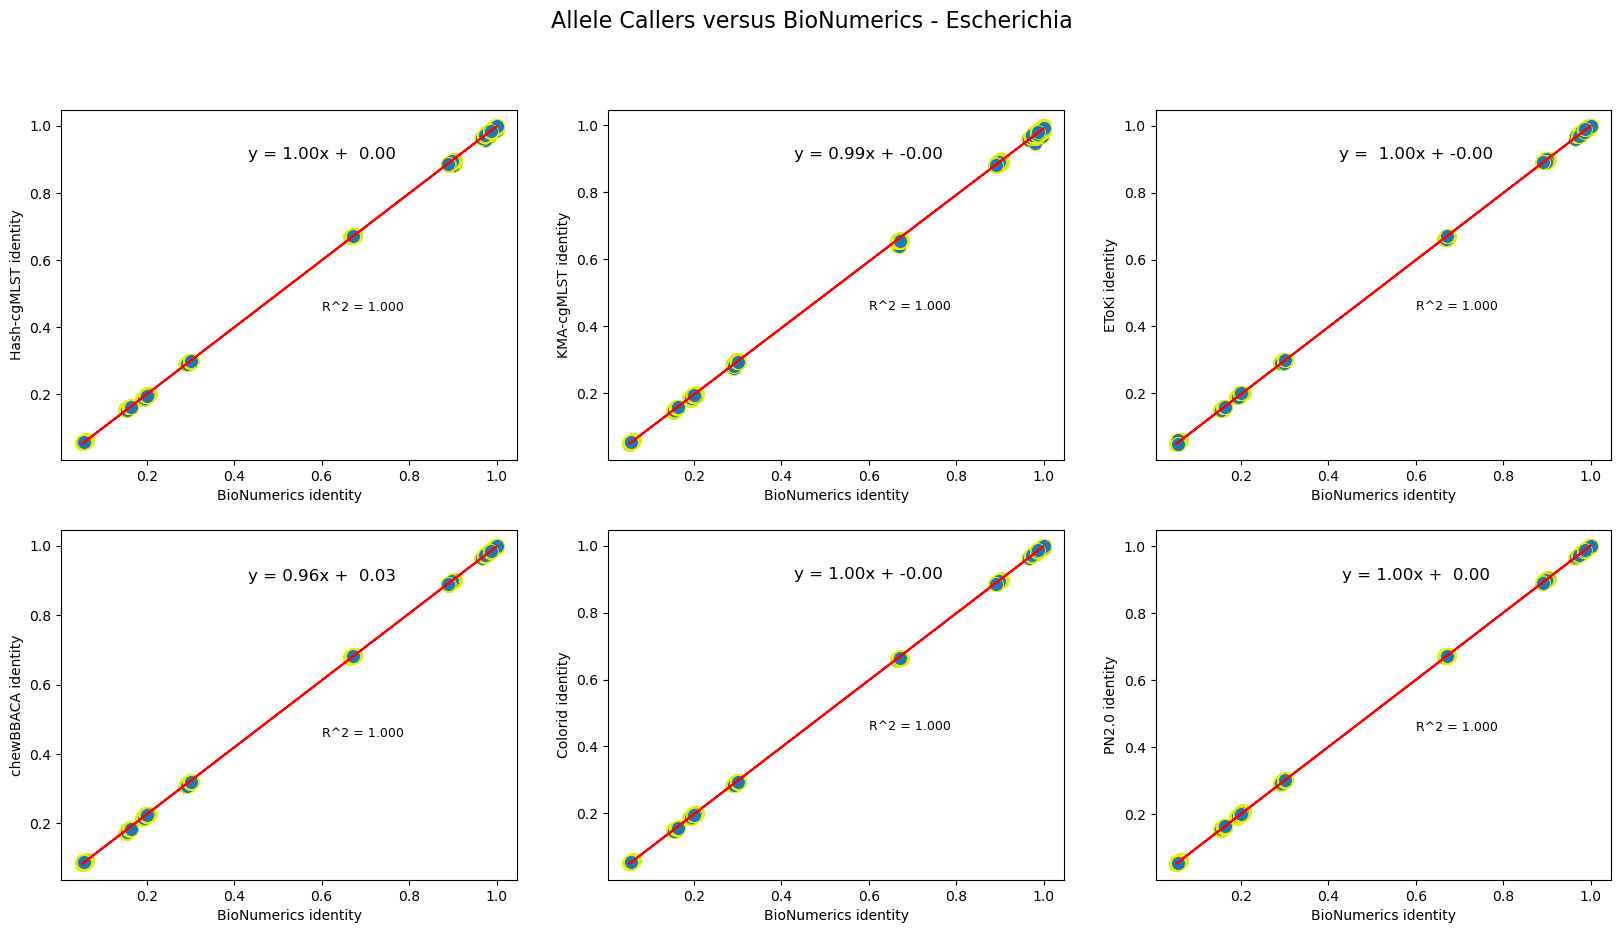

In [19]:
fig_grid,axs = plt.subplots(2,3, figsize=(20,10))
fig_grid.suptitle('Allele Callers versus BioNumerics - Escherichia',fontsize=16)
axs[0][0].scatter(x1,y1,edgecolor="yellow",linewidth=0.5,s=100)
axs[0][0].plot(x1,yPred,color="red")
# axs[0].set_title("hash-cgMLST versus BioNumerics identities for Escherichia")
axs[0][0].set_xlabel('BioNumerics identity')
axs[0][0].set_ylabel('Hash-cgMLST identity')
axs[0][0].text(0.6, 0.9, regEq, fontsize=12, ha="center")
axs[0][0].annotate("R^2 = {:.3f}".format(r2_score(y1, yPred)),(0.6,0.45),fontsize=9)

#kma-cgmlst
axs[0][1].scatter(x2,y2,edgecolor="yellow",linewidth=0.5,s=100)
axs[0][1].plot(x2,y2Pred,color="red")
# axs[1].set_title("kma-cgmlst versus BioNumerics identities for Escherichia")
axs[0][1].set_xlabel('BioNumerics identity')
axs[0][1].set_ylabel('KMA-cgMLST identity')
axs[0][1].text(0.6, 0.9, regEq2, fontsize=12, ha="center")
axs[0][1].annotate("R^2 = {:.3f}".format(r2_score(y2, y2Pred)),(0.6,0.45),fontsize=9)

#etoki
axs[0][2].scatter(x3,y3,edgecolor="yellow",linewidth=0.5,s=100)
axs[0][2].plot(x3,y3pred,color="red")
# axs[2].set_title("EToKi versus BioNumerics identities for Salmonella")
axs[0][2].set_xlabel('BioNumerics identity')
axs[0][2].set_ylabel('EToKi identity')
axs[0][2].text(0.6, 0.9, regEq3, fontsize=12, ha="center")
axs[0][2].annotate("R^2 = {:.3f}".format(r2_score(y3, y3pred)),(0.6,0.45),fontsize=9)

#chewBBACA
axs[1][0].scatter(x4,y4,edgecolor="yellow",linewidth=0.5,s=100)
axs[1][0].plot(x4,y4Pred,color="red")
# axs[1][0].set_title("colorID versus BioNumerics identities for Campylobacter")
axs[1][0].set_xlabel('BioNumerics identity')
axs[1][0].set_ylabel('chewBBACA identity')
axs[1][0].text(0.6, 0.9, regEq4, fontsize=12, ha="center")
axs[1][0].annotate("R^2 = {:.3f}".format(r2_score(y4, y4Pred)),(0.6,0.45),fontsize=9)

#ColorID
axs[1][1].scatter(x5,y5,edgecolor="yellow",linewidth=0.5,s=100)
axs[1][1].plot(x5,y5Pred,color="red")
# axs[4].set_title("chewBBACA versus BioNumerics identities for Campylobacter")
axs[1][1].set_xlabel('BioNumerics identity')
axs[1][1].set_ylabel('Colorid identity')
axs[1][1].text(0.6, 0.9, regEq5, fontsize=12, ha="center")
axs[1][1].annotate("R^2 = {:.3f}".format(r2_score(y5, y5Pred)),(0.6,0.45),fontsize=9)

#pn2.0
axs[1][2].scatter(x6,y6,edgecolor="yellow",linewidth=0.5,s=100)
axs[1][2].plot(x6,y6Pred,color="red")
# axs[5].set_title("PN2.0 versus BioNumerics identities for Campylobacter")
axs[1][2].set_xlabel('BioNumerics identity')
axs[1][2].set_ylabel('PN2.0 identity')
axs[1][2].text(0.6, 0.9, regEq6, fontsize=12, ha="center")
axs[1][2].annotate("R^2 = {:.3f}".format(r2_score(y6, y6Pred)),(0.6,0.45),fontsize=9)

# plt.savefig("/scicomp/home-pure/uge1/MLST/figures_data/escherichia_allcallersVsBN_corrected.png")